# Aim 3
Tara Cornwell June 2024

Adapted from Darici and Kuo

### First, let's simulate unperturbed and perturbed step conditions.

In [61]:
# Import necessary packages
using DynLoco_TC, Plots; 

# Create structure for "walk"
wstar = findgait(WalkRW2lvs(α=0.28,safety=true), target=:speed=>0.42, varying=:P)

# Set number of steps: pre, pert, recovery
nsteps = 5

# Setup perturbation vector
perts = [1 1 1.5 1 1]

# Run optimization that minimizes push-off work
nominal_result = optwalk_TC(wstar, nsteps, boundaryvels=(wstar.vm, wstar.vm), boundarywork=false)
pert_result = optwalk_TC(wstar, nsteps, boundaryvels=(wstar.vm, wstar.vm), boundarywork=false, perts=perts)

# Apply naive control to perturbation condition
naive_result = multistep(wstar; Ps=nominal_result.steps.P,boundaryvels=(wstar.vm, wstar.vm), perts=perts)

# Print results
println("Without pert, total work cost = ", nominal_result.workcost)
println("With pert considered in opt, total work cost = ", pert_result.workcost)
println("With pert not considered in opt, total work cost = ", naive_result.workcost)

Without pert, total work cost = 0.10649684084184041
With pert considered in opt, total work cost = 0.07649701626088481
With pert not considered in opt, total work cost = 0.10649684084184041


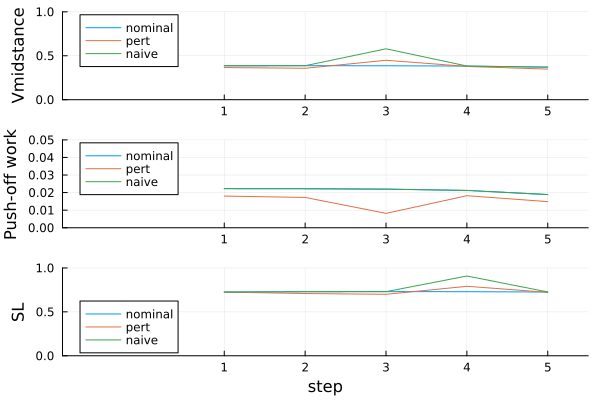

In [73]:
# Plots
l = @layout [a; b; c]

p1 = plot(nominal_result.steps.vm, label="nominal")
plot!(pert_result.steps.vm, ylabel="Vmidstance", label="pert")
plot!(naive_result.steps.vm, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(nominal_result.steps.Pwork, ylabel="Push-off work", label="nominal")
plot!(pert_result.steps.Pwork, label="pert")
plot!(naive_result.steps.Pwork, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.01:0.05)

p3 = plot(nominal_result.steps.steplength, xlabel="step", ylabel="SL", label="nominal")
plot!(pert_result.steps.steplength, label="pert")
plot!(naive_result.steps.steplength, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Now let's try using the MPC controller.

In [63]:
# Run optimization that minimizes push-off work

nhorizon=1
mpc_result1 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=2
mpc_result2 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=3
mpc_result3 = mpcstep(wstar, nsteps, nhorizon, perts=perts)

nhorizon=nsteps
mpc_result_full = mpcstep(wstar, nsteps, nhorizon, perts=perts)

# Print results
println("With horizon = 1, PO work cost = ", mpc_result1.workcost)
println("With horizon = 2, PO work cost = ", mpc_result2.workcost)
println("With horizon = 3, PO work cost = ", mpc_result3.workcost)
println("With full horizon, PO work cost = ", mpc_result_full.workcost)

With horizon = 1, PO work cost = 0.08431323263188448
With horizon = 2, PO work cost = 0.08235653657440495
With horizon = 3, PO work cost = 0.08658039595923107
With full horizon, PO work cost = 0.08885536942463829


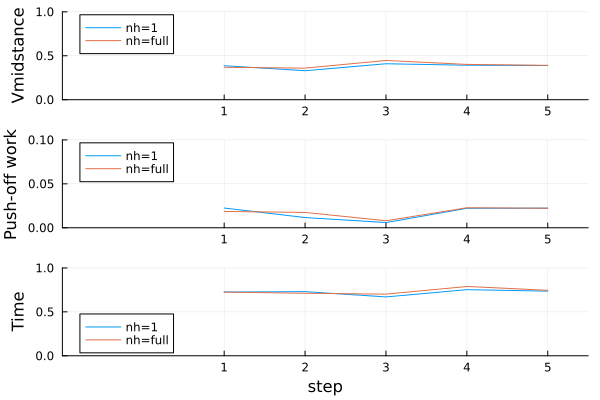

In [76]:
# Plots
l = @layout [a; b; c]

p1 = plot(mpc_result1.steps.vm, label="nh=1")
#plot!(mpc_result2.steps.vm, label="nh=2")
#plot!(mpc_result3.steps.vm, label="nh=3")
plot!(mpc_result_full.steps.vm, ylabel="Vmidstance", label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mpc_result1.steps.Pwork, ylabel="Push-off work", label="nh=1")
#plot!(mpc_result2.steps.Pwork, label="nh=2")
#plot!(mpc_result3.steps.Pwork, label="nh=3")
plot!(mpc_result_full.steps.Pwork, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(mpc_result1.steps.steplength, xlabel="step", ylabel="Time", label="nh=1")
#plot!(mpc_result2.steps.steplength, label="nh=2")
#plot!(mpc_result3.steps.steplength, label="nh=3")
plot!(mpc_result_full.steps.steplength, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Test different weights on objective function

In [65]:
nhorizon=nsteps

result_0 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0)
result_1 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=1)
result_5 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0.5)
result_8 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0.8)
result_01 = mpcstep(wstar, nsteps, nhorizon, perts=perts, weight=0.1)

# Print results
println("Min. work alone, work cost = ", result_0.workcost)
println("Min. changes in step time alone, work cost = ", result_1.workcost)
#println("Min. both work and changes to step time equally, work cost = ", result_5.workcost)
println("Min. both work and changes to step time (w=0.8), work cost = ", result_01.workcost)

Min. work alone, work cost = 0.08885536942463829
Min. changes in step time alone, work cost = 0.08290263022119868
Min. both work and changes to step time (w=0.8), work cost = 0.0871834494577421


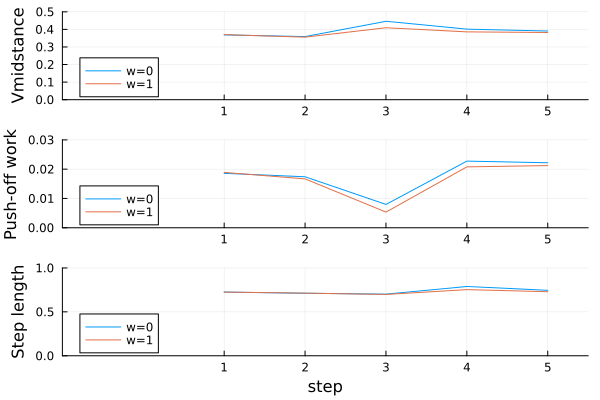

In [68]:
# Plots
l = @layout [a; b; c]

p1 = plot(result_0.steps.vm, ylabel="Vmidstance", label="w=0")
#plot!(result_01.steps.vm, label="w=0.1")
#plot!(result_5.steps.vm, label="w=0.5")
#plot!(result_8.steps.vm, label="w=0.8")
plot!(result_1.steps.vm, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.5), xticks = 1:1:nsteps, yticks = 0:0.1:0.5)

p2 = plot(result_0.steps.Pwork, ylabel="Push-off work", label="w=0")
#plot!(result_01.steps.Pwork, label="w=0.1")
#plot!(result_5.steps.Pwork, label="w=0.5")
#plot!(result_8.steps.Pwork, label="w=0.8")
plot!(result_1.steps.Pwork, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.03), xticks = 1:1:nsteps, yticks = 0:0.01:0.03)

#p3 = plot(result_0.steps.tf, ylabel="Time", label="w=0")
#plot!(result_01.steps.tf, label="w=0.1")
#plot!(result_5.steps.tf, label="w=0.5")
#plot!(result_8.steps.tf, label="w=0.8")
#plot!(result_1.steps.tf, label="w=1")
#plot!(xlims = (-1, nsteps+0.5), xticks = 1:1:nsteps)
#plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

p4 = plot(result_0.steps.steplength, xlabel="step", ylabel="Step length", label="w=0")
#plot!(result_01.steps.steplength, label="w=0.1")
#plot!(result_5.steps.steplength, label="w=0.5")
#plot!(result_8.steps.steplength, label="w=0.8")
plot!(result_1.steps.steplength, label="w=1")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p4, layout = l)

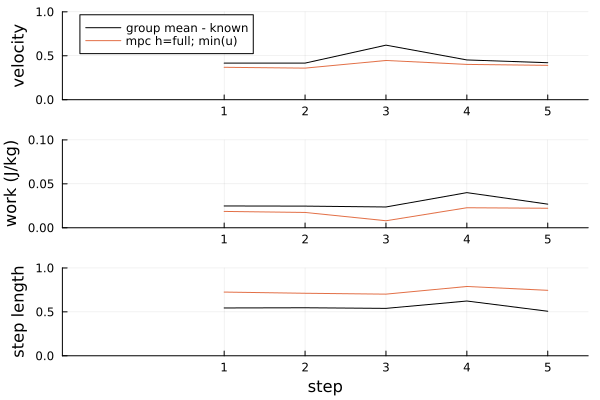

In [77]:
# Import experimental data
using CSV, DataFrames, Plots, Statistics

df_M = CSV.read("M.csv", header=["kg"], DataFrame) # mass
df_H = CSV.read("H.csv", header=["m"], DataFrame) # height
df_V = CSV.read("V.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U = CSV.read("U.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL = CSV.read("SL.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST = CSV.read("ST.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

# Plots
l = @layout [a; b; c]

g = 9.81
L = 1
M = 1
norm_v = (g^0.5)*(L^0.5)
norm_u = g*L # already mass-normalized

p1 = plot(mean(transpose(Matrix(df_V[:,2:6])),dims=2)/norm_v, linecolor =:black, ylabel="velocity", label="group mean - known")
plot!(result_0.steps.vm, label="mpc h=full; min(u)")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mean(transpose(Matrix(df_U[:,1:5])),dims=2)/norm_u, linecolor =:black, ylabel="work (J/kg)", label=false)
plot!(result_0.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(mean(transpose(Matrix(df_SL[:,2:6])),dims=2), linecolor =:black, xlabel="step", ylabel="step length", label=false)
plot!(result_0.steps.steplength, xlabel="step", label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

For an unexpected perturbation, implement reactive balance (i.e., no change in control until after perturbation occurs)

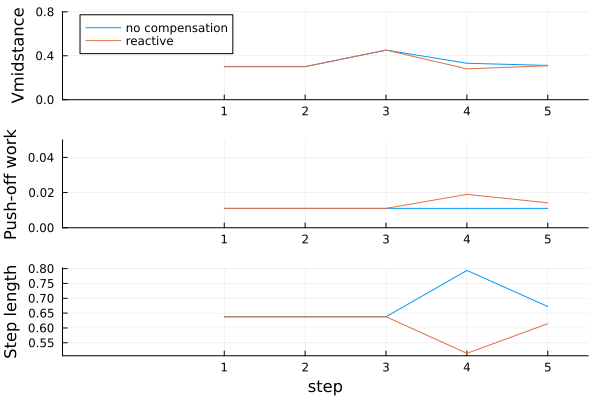

In [46]:
nocomp_result = multistep(wstar, Ps=fill(wstar.P,nsteps),perts = perts)

reactive_result1 = multistep(wstar, Ps=fill(wstar.P,3), perts = [1 1 1.5])
reactive_result2 = optwalk_TC(wstar, nsteps-3, boundaryvels=(reactive_result1.steps[end].vm,wstar.vm), perts =[1 1])

# Plots
l = @layout [a; b; c]

p1 = plot(nocomp_result.steps.vm, ylabel="Vmidstance", label="no compensation")
plot!([reactive_result1.steps.vm; reactive_result2.steps.vm], label="reactive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.8), xticks = 1:1:nsteps, yticks = 0:0.4:0.8)

p2 = plot(nocomp_result.steps.Pwork, ylabel="Push-off work", label=false)
plot!([reactive_result1.steps.Pwork; reactive_result2.steps.Pwork], label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.02:0.05)

p3 = plot(nocomp_result.steps.steplength, xlabel="step", ylabel="Step length", label=false)
plot!([reactive_result1.steps.steplength; reactive_result2.steps.steplength], label=false)
plot!(xlims = (-1, nsteps+0.5), xticks = 1:1:nsteps)

plot(p1, p2, p3, layout = l)